## Задание
Продолжаем работать с объединенным датасетом merged_data

**Задача 1** 

Цель: выделить пользователей, которые делают упор на индивидуальные тренировки.

Что сделать:
Выберите пользователей, у которых >70% тренировок — индивидуальные.
Для этих пользователей:
+ Посчитайте средний чек;
+ Посчитайте среднее число тренировок в месяц;
+ Разбейте их по городам и полу.

Вопросы для анализа:

+ Кто чаще выбирает индивидуальные тренировки?
+ Есть ли зависимость от пола или города?
+ Насколько высок средний чек у таких пользователей?

**Задача 2.**
Найдите 10 пользователей с наибольшим общим количеством посещений (групповые + индивидуальные тренировки) за весь период наблюдения.

Что нужно сделать:

+ Рассчитайте общее количество тренировок для каждого пользователя.

+ Определите 10 самых активных пользователей и сохраните их идентификаторы в виде списка.

Постройте распределение этих пользователей по:

+ городу
+ полу

Вопросы для анализа:
+ В каких городах больше всего супер-активных клиентов?
+ Какого они пола?

**Задача 3** 
Ваша цель — проанализировать, как менялась клиентская база по месяцам:
сколько клиентов приходило, сколько уходило и сколько оставалось активными.

Шаги:
+ Новые клиенты — это те, у кого первый месяц появления (минимальный mon в данных).

+ Ушедшие клиенты — это те, у кого последний месяц активности (максимальный mon в данных).

+ Активные клиенты — это те, кто был активен в конкретном месяце.

Что нужно сделать:
Рассчитайте три метрики для каждого месяца:
+ new_clients: количество клиентов, для которых этот месяц — первый.
+ gone_clients: количество клиентов, для которых этот месяц — последний.
+ active_clients: общее количество уникальных клиентов в этом месяце.

Для этого:
Создайте три отдельных датафрейма:

+ с новыми клиентами по месяцам,
+ с ушедшими клиентами по месяцам,
+ с активными клиентами по месяцам.

Объедините их по полю mon.

Постройте линейный график с тремя линиями.



In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head(3)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female


### Задача 1. Пользователи с 70%+ инд.тренировок

In [50]:
users = df.groupby(['id_user', 'city', 'gender']).agg({'mon':'count',
                                               'cnt_total':'sum',
                                               'cnt_indiv':'sum',
                                               'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonths'})
users

,id_user,city,gender,nmonths,cnt_total,cnt_indiv,sum_total
0,1000,СПб,female,9,33,33,58600
1,1001,Москва,female,11,129,23,124800
2,1002,Москва,male,11,128,64,166000
3,1004,Екатеринбург,male,9,18,18,32000
4,1005,СПб,female,2,7,7,12600
...,...,...,...,...,...,...,...
833,1992,СПб,male,4,39,12,43200
834,1993,СПб,male,2,24,2,22000
835,1994,Казань,male,1,7,0,5600
836,1995,Москва,female,2,23,0,18400


In [51]:
users['share_indiv'] = users['cnt_indiv']/users['cnt_total']
users_s = users[users['share_indiv']>0.7]
users_s.head()

,id_user,city,gender,nmonths,cnt_total,cnt_indiv,sum_total,share_indiv
0,1000,СПб,female,9,33,33,58600,1.0
3,1004,Екатеринбург,male,9,18,18,32000,1.0
4,1005,СПб,female,2,7,7,12600,1.0
6,1007,Москва,female,4,5,5,9000,1.0
8,1009,Москва,female,4,9,9,16200,1.0


In [52]:
users_s = users_s.copy()
users_s['avg_check_per_mon'] = users_s['sum_total']/users_s['nmonths']
users_s['avg_train_per_mon'] = users_s['cnt_total']/users_s['nmonths']
users_s

,id_user,city,gender,nmonths,cnt_total,cnt_indiv,sum_total,share_indiv,avg_check_per_mon,avg_train_per_mon
0,1000,СПб,female,9,33,33,58600,1.0,6511.111111,3.666667
3,1004,Екатеринбург,male,9,18,18,32000,1.0,3555.555556,2.000000
4,1005,СПб,female,2,7,7,12600,1.0,6300.000000,3.500000
6,1007,Москва,female,4,5,5,9000,1.0,2250.000000,1.250000
8,1009,Москва,female,4,9,9,16200,1.0,4050.000000,2.250000
...,...,...,...,...,...,...,...,...,...,...
824,1982,Москва,female,7,22,22,39000,1.0,5571.428571,3.142857
825,1983,СПб,female,1,6,6,10800,1.0,10800.000000,6.000000
827,1985,Екатеринбург,female,3,10,10,18000,1.0,6000.000000,3.333333
830,1988,Екатеринбург,female,5,18,18,32400,1.0,6480.000000,3.600000


In [53]:
users_s2 = users_s.groupby(['city', 'gender']).agg({'id_user': 'nunique',
                                                    'avg_check_per_mon':'mean',
                                                    'avg_train_per_mon':'mean'}).reset_index().rename(columns = {'id_user':'nusers'})
users_s2

,city,gender,nusers,avg_check_per_mon,avg_train_per_mon
0,Екатеринбург,female,12,5391.746032,3.009524
1,Екатеринбург,male,12,5832.394180,3.256184
2,Казань,female,8,6297.500000,3.756250
3,Казань,male,12,5229.378307,2.931548
4,Москва,female,118,5565.425624,3.141311
5,Москва,male,59,6915.316115,3.872733
6,СПб,female,32,6093.278770,3.399777
7,СПб,male,28,5024.889456,2.821443


In [54]:
avg_check = users_s2['avg_check_per_mon'].mean()
print (avg_check)

5793.741060446286


In [55]:
users_s2.groupby(['gender']).agg({'nusers':'sum'})

,nusers
gender,
female,170
male,111


In [56]:
#1. Мужчины чаще выбирают индивидуальные тренировки.
#2. Индивидуальные тренировки в Москве и СПб чаще выбирают женщины.
#3. Средний чек таких пользователей около 5800 р.

### Задача 2. Топ-10 клиентов

In [57]:
df = pd.read_csv('merged_data.csv')
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


In [58]:
users_max_train = df.groupby(['id_user', 'city', 'gender']).agg({'cnt_total':'sum'}).reset_index().sort_values('cnt_total', ascending = False).head(10)
users_max_train

,id_user,city,gender,cnt_total
319,1381,Москва,female,159
12,1013,Москва,male,151
551,1657,СПб,male,144
420,1506,Москва,female,138
780,1929,Москва,male,130
1,1001,Москва,female,129
474,1570,Екатеринбург,male,129
2,1002,Москва,male,128
485,1582,Екатеринбург,male,127
168,1194,СПб,female,127


In [59]:
user_lst = users_max_train['id_user'].tolist()
user_lst

[1381, 1013, 1657, 1506, 1929, 1001, 1570, 1002, 1582, 1194]

In [60]:
df_top = df[df['id_user'].isin(user_lst)]
df_top.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female
10,1001,2023-02,11,3,8800,5400,14,14200,2023-01,2023-12,Москва,35.0,female
11,1001,2023-03,8,6,6400,10800,14,17200,2023-01,2023-12,Москва,35.0,female
12,1001,2023-04,9,5,7200,9000,14,16200,2023-01,2023-12,Москва,35.0,female
13,1001,2023-05,3,7,2400,11200,10,13600,2023-01,2023-12,Москва,35.0,female


In [61]:
user_top = df_top.groupby(['id_user', 'city', 'gender']).agg({'cnt_total':'sum'}).reset_index()
user_top

,id_user,city,gender,cnt_total
0,1001,Москва,female,129
1,1002,Москва,male,128
2,1013,Москва,male,151
3,1194,СПб,female,127
4,1381,Москва,female,159
5,1506,Москва,female,138
6,1570,Екатеринбург,male,129
7,1582,Екатеринбург,male,127
8,1657,СПб,male,144
9,1929,Москва,male,130


In [62]:
user_top['city'].value_counts()

city
Москва          6
СПб             2
Екатеринбург    2
Name: count, dtype: int64

In [63]:
user_top['gender'].value_counts()

gender
male      6
female    4
Name: count, dtype: int64

In [64]:
# 1. Больше всего суперактивных клиентов в Москве.
# 2. Среди суперактивных клиентов больше мужчин.

### Задача 3. Динамика клиентской базы

In [65]:
df = pd.read_csv('merged_data.csv')
df['mon'] = pd.to_datetime(df['mon'], format = "%Y-%m")
df['min_mon'] = pd.to_datetime(df['min_mon'], format = "%Y-%m")
df['max_mon'] = pd.to_datetime(df['max_mon'], format = "%Y-%m")
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03-01,0,2,0,3600,2,3600,2023-03-01,2023-12-01,СПб,44.0,female
1,1000,2023-04-01,0,4,0,7200,4,7200,2023-03-01,2023-12-01,СПб,44.0,female
2,1000,2023-05-01,0,4,0,6400,4,6400,2023-03-01,2023-12-01,СПб,44.0,female
3,1000,2023-06-01,0,2,0,3600,2,3600,2023-03-01,2023-12-01,СПб,44.0,female
4,1000,2023-07-01,0,4,0,7200,4,7200,2023-03-01,2023-12-01,СПб,44.0,female


In [66]:
first_month_per_client = df.groupby('id_user')['mon'].min().reset_index()
new_clients_df = first_month_per_client.groupby('mon').agg(new_clients=('id_user', 'nunique')).reset_index().sort_values('mon')

In [67]:
last_month_per_client = df.groupby('id_user')['mon'].max().reset_index()
gone_clients_df = last_month_per_client.groupby('mon').agg(gone_clients=('id_user', 'nunique')).reset_index().sort_values('mon')

In [68]:
active_clients_df = df.groupby('mon').agg(active_clients=('id_user', 'nunique')).reset_index().sort_values('mon')

In [69]:
summary_df = new_clients_df.merge(gone_clients_df, on='mon', how='left').merge(active_clients_df, on='mon', how='left')
summary_df

,mon,new_clients,gone_clients,active_clients
0,2023-01-01,337,15,337
1,2023-02-01,88,22,350
2,2023-03-01,83,37,355
3,2023-04-01,62,21,345
4,2023-05-01,57,21,360
5,2023-06-01,51,13,383
6,2023-07-01,48,33,412
7,2023-08-01,35,33,423
8,2023-09-01,28,55,429
9,2023-10-01,27,101,441


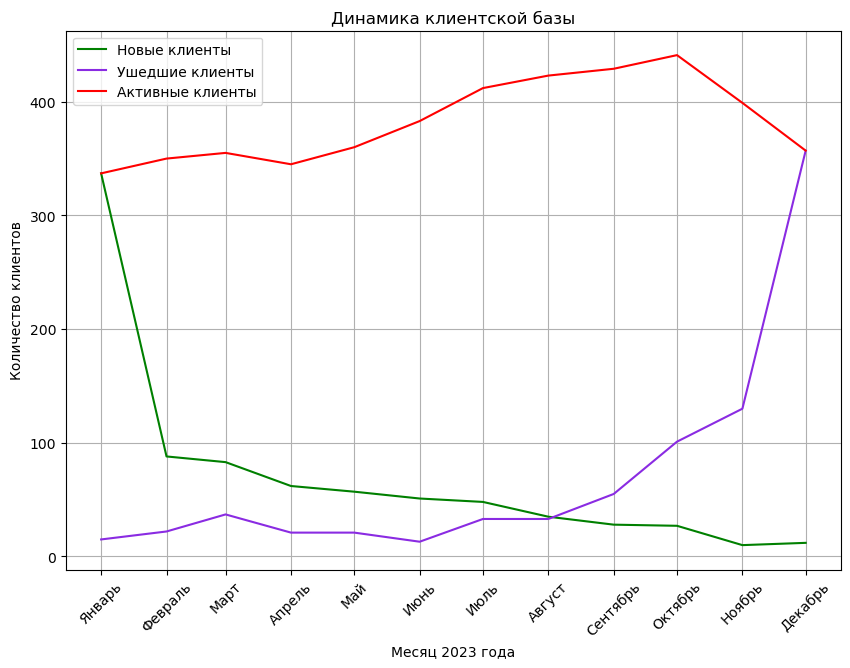

In [70]:
months = ['Январь','Февраль','Март','Апрель','Май','Июнь','Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 7))
x = summary_df['mon']
y = summary_df['new_clients']
z = summary_df['gone_clients']
o = summary_df['active_clients']
ax.plot(x,y,'g', label = 'Новые клиенты')
ax.plot(x,z,'blueviolet', label = 'Ушедшие клиенты')
ax.plot(x,o,'r', label = 'Активные клиенты')
ax.set_xlabel('Месяц 2023 года')
ax.set(xticks=summary_df['mon'], xticklabels=months)
ax.xaxis.set_tick_params(rotation=45)
ax.set_ylabel('Количество клиентов')
ax.set_title('Динамика клиентской базы')
ax.grid()
ax.legend(loc='upper left')
plt.show()

In [71]:
summary_df.iloc[0, 1] = np.nan  #значение удалено, так как происходит искажение данных, так как не все клиенты пришли именно в этом январе
summary_df.iloc[11, 2] = np.nan #значение удалено, так как происходит искажение данных, так как не все клиенты ушли именно в этом декабре
summary_df

,mon,new_clients,gone_clients,active_clients
0,2023-01-01,NaN,15.0,337
1,2023-02-01,88.0,22.0,350
2,2023-03-01,83.0,37.0,355
3,2023-04-01,62.0,21.0,345
4,2023-05-01,57.0,21.0,360
5,2023-06-01,51.0,13.0,383
6,2023-07-01,48.0,33.0,412
7,2023-08-01,35.0,33.0,423
8,2023-09-01,28.0,55.0,429
9,2023-10-01,27.0,101.0,441


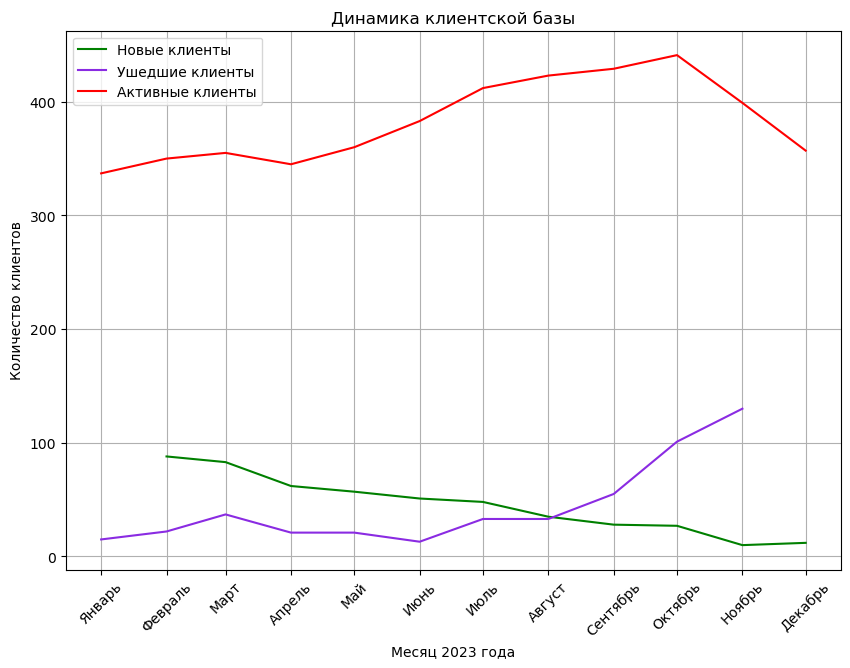

In [72]:
months = ['Январь','Февраль','Март','Апрель','Май','Июнь','Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 7))
x = summary_df['mon']
y = summary_df['new_clients']
z = summary_df['gone_clients']
o = summary_df['active_clients']
ax.plot(x,y,'g', label = 'Новые клиенты')
ax.plot(x,z,'blueviolet', label = 'Ушедшие клиенты')
ax.plot(x,o,'r', label = 'Активные клиенты')
ax.set_xlabel('Месяц 2023 года')
ax.set(xticks=summary_df['mon'], xticklabels=months)
ax.xaxis.set_tick_params(rotation=45)
ax.set_ylabel('Количество клиентов')
ax.set_title('Динамика клиентской базы')
ax.grid()
ax.legend(loc='upper left')
plt.show()